## Cargando librerias

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import joblib


## Cargando Tabla limpia

In [61]:
df = pd.read_csv("../processed/df_total_clean_CA1.csv")

/var/folders/m_/06pskt392pn6qvkq92krm8xm0000gn/T/ipykernel_46211/3820689758.py:1: DtypeWarning: Columns (14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../processed/df_total_clean_CA1.csv")


In [62]:
df["date"] = pd.to_datetime(df["date"])

### Creación features temporales 

In [63]:
df = df.sort_values(["item_id", "date"])

#### Lags 
El valor pasado de una variables.\
Usa el pasado para predecir el futuro.

In [64]:
df["lag_7"] = df.groupby("item_id")["sales"].shift(7)
df["lag_28"] = df.groupby("item_id")["sales"].shift(28)

#### Rolling Mean 

Es un promedio móvil. Es el promedio de los últimos N días 

In [65]:
# usamos .shift(1) para evitar leakage.
df["rolling_mean_7"] = (
    df.groupby("item_id")["sales"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

In [66]:
df["rolling_mean_28"] = (
    df.groupby("item_id")["sales"]
    .shift(1)
    .rolling(window=28)
    .mean()
)

In [67]:
# variables temporales útiles
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["dayofweek"] = df["date"].dt.dayofweek

In [68]:
df.isnull().sum()

id                       0
item_id                  0
dept_id                  0
cat_id                   0
store_id                 0
state_id                 0
d                        0
sales                    0
date                     0
wm_yr_wk                 0
weekday                  0
wday                     0
month                    0
year                     0
event_name_1       4326129
event_type_1       4326129
event_name_2       4693212
event_type_2       4693212
snap_CA                  0
snap_TX                  0
snap_WI                  0
has_event                0
sell_price               0
is_weekend               0
lag_7                21343
lag_28               85372
rolling_mean_7       21343
rolling_mean_28      85372
dayofweek                0
dtype: int64

In [69]:
# Como tengo has_event elimino las columnas de eventos que no la usare 
df = df.drop(columns=["event_name_1", "event_type_1", "event_name_2", "event_type_2"])

In [70]:
# Eliminamos los NaN que se crearon por el rolling 7, 28 y los lag 7, 28
df = df.dropna(subset=["lag_7", "lag_28", "rolling_mean_7", "rolling_mean_28"])

In [71]:
df.shape

(4617523, 25)

### Definiendo features Baseline

In [ ]:
features = ["sell_price",
            "is_weekend",
            "has_event",
            "dayofweek",
            "month",
            "year",
            "lag_7",
            "lag_28",
            "rolling_mean_7",
            "rolling_mean_28"]

In [73]:
target = "sales"

### Split Temporal 

In [74]:
train = df[df["date"] < "2015-01-01"]
test  = df[df["date"] >= "2015-01-01"]

In [75]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [76]:
# porque mi dataset es muy grande
train_sample = train.sample(200000, random_state=42)

X_train_sample = train_sample[features]
y_train_sample = train_sample[target]

### Modelo baseline

In [77]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_sample, y_train_sample)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
preds = model.predict(X_test)


In [79]:
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.2193409368613244
MAE: 1.1019176852723822


Modelo Random Forest:\
Mi media de ventas estaba alrededor de ~ 1.3 unidades por día.

* MAE ~ 1.10 -> el error promedio es casi del tamaño de la venta media
* RMSE ~ 2.19 -> hay errores grandes (penaliza más outliers)

In [80]:
#la predicción para hoy será igual a lo que vendí hace días - > modelo naive semanal
baseline_preds = X_test["lag_7"]
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_preds))
mae_baseline = mean_absolute_error(y_test, baseline_preds)

print("Baseline RMSE:", rmse_baseline)
print("Baseline MAE:", mae_baseline)

Baseline RMSE: 2.8588989513488112
Baseline MAE: 1.277839649004758


Tu modelo mejora respecto al baseline:

RMSE mejora ≈
(2.86 - 2.21) / 2.86 ≈ 20% de mejora

MAE mejora ≈
(1.28 - 1.10) / 1.28 ≈ 14% de mejora

Eso es una mejora clara y significativa.

In [81]:
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

importance

rolling_mean_7     0.525062
rolling_mean_28    0.241621
lag_7              0.054067
sell_price         0.047940
lag_28             0.040572
month              0.031717
dayofweek          0.031485
year               0.015253
is_weekend         0.007665
has_event          0.004619
dtype: float64

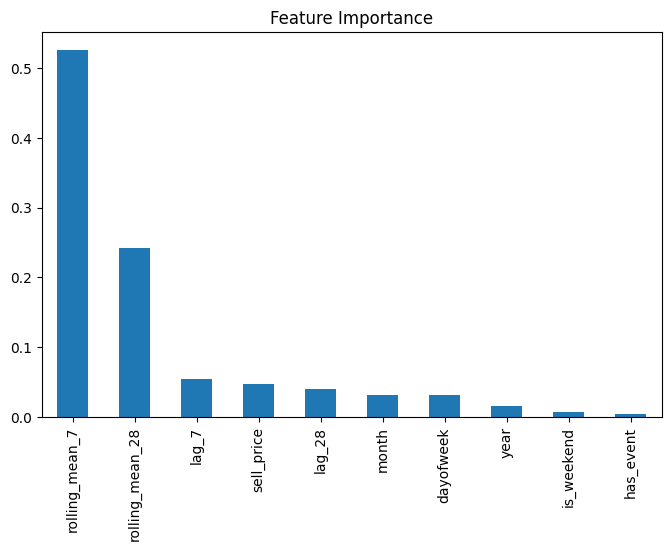

In [82]:
importance.plot(kind="bar", figsize=(8,5))
plt.title("Feature Importance")
plt.show()

## Modelo Random Forest Regressor 

In [83]:
# para análisis de tiempo 
tscv = TimeSeriesSplit(n_splits=3)

In [84]:
param_rf = {
    "n_estimators": [200, 300, 400],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.8]
}

In [85]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

In [86]:
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_rf,
    n_iter=15,
    cv=tscv,
    scoring="neg_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1)

In [87]:
rf_search.fit(X_train_sample, y_train_sample)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 0.8], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,15
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [88]:
best_rf = rf_search.best_estimator_

In [89]:
preds_rf = best_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, preds_rf))
mae_rf = mean_absolute_error(y_test, preds_rf)

print("Optimized RF RMSE:", rmse_rf)
print("Optimized RF MAE:", mae_rf)

Optimized RF RMSE: 2.1311670040593746
Optimized RF MAE: 1.045589736819908


### Gradient Boosting con RandomizedRegressor  

In [90]:
# para análisis de tiempo 
tscv = TimeSeriesSplit(n_splits=3)

In [91]:
param_gb = {
    "n_estimators": [200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5]}

In [92]:
gb = GradientBoostingRegressor(random_state=42)

In [93]:
gb_search = RandomizedSearchCV(
    gb,
    param_distributions=param_gb,
    n_iter=10,
    cv=tscv,
    scoring="neg_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1)

In [94]:
gb_search.fit(X_train_sample, y_train_sample)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'min_samples_split': [2, 5], 'n_estimators': [200, 300]}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [95]:
best_gb = gb_search.best_estimator_

In [96]:
preds_gb = best_gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, preds_gb))
mae_gb = mean_absolute_error(y_test, preds_gb)

print("Optimized GB RMSE:", rmse_gb)
print("Optimized GB MAE:", mae_gb)

Optimized GB RMSE: 2.152690504438866
Optimized GB MAE: 1.0472046898308252


#### XGBRegressor

In [97]:
param_xgb = {
    "n_estimators": [300, 500],
    "learning_rate": [0.03, 0.05],
    "max_depth": [4, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]}

In [98]:
xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

In [99]:
xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_xgb,
    n_iter=15,
    cv=tscv,
    scoring="neg_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1)

In [100]:
xgb_search.fit(X_train_sample, y_train_sample)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05], 'max_depth': [4, 6], 'n_estimators': [300, 500], ...}"
,n_iter,15
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [101]:
best_xgb = xgb_search.best_estimator_

In [102]:
preds_xgb = best_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))
mae_xgb = mean_absolute_error(y_test, preds_xgb)

print("Optimized XGB RMSE:", rmse_xgb)
print("Optimized XGB MAE:", mae_xgb)

Optimized XGB RMSE: 2.1705546585227395
Optimized XGB MAE: 1.0499699115753174


#### comparación entre todos los modelos

In [103]:
results = {
    "Random Forest": [rmse_rf, mae_rf],
    "Gradient Boosting": [rmse_gb, mae_gb],
    "XGBoost": [rmse_xgb, mae_xgb]
}

results_df = pd.DataFrame(results, index=["RMSE", "MAE"]).T
results_df.sort_values("RMSE")

,RMSE,MAE
Random Forest,2.131167,1.045590
Gradient Boosting,2.152691,1.047205
XGBoost,2.170555,1.049970


Se compararon tres modelos de machine learning: Random Forest, Gradient Boosting y XGBoost.\
Random Forest obtuvo el menor error de predicción (RMSE = 2.13, MAE = 1.04), mostrando un mejor equilibrio entre precisión y estabilidad.\
Las diferencias entre modelos fueron pequeñas, lo que sugiere que la variabilidad de la demanda y la naturaleza intermitente de las ventas limitan la mejora adicional mediante modelos más complejos.\
Para comparar modelos de regresión / forecasting se usan métricas de error. En tus resultados cuanto más bajo, mejor.

### Modelo escogido Random Forest

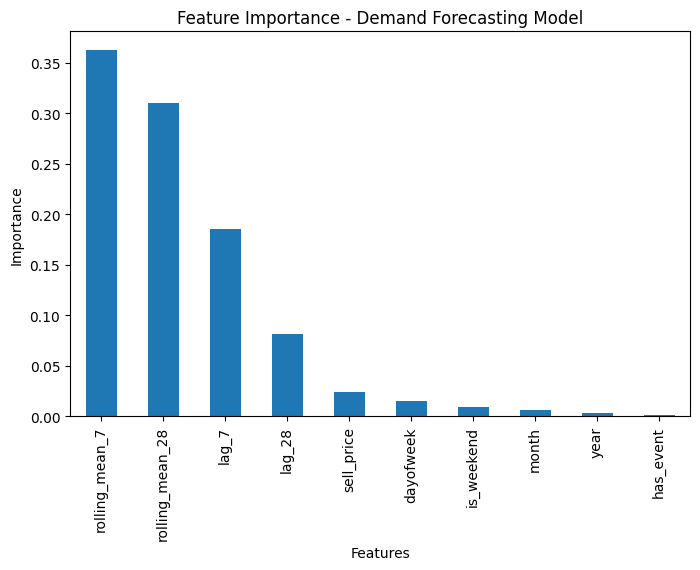

In [104]:
importance = pd.Series(best_rf.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.title("Feature Importance - Demand Forecasting Model")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.show()

In [105]:
#grafico de prediccion vs real 
results = pd.DataFrame({
    "date": test["date"],
    "actual": y_test,
    "predicted": preds_rf
})

In [106]:
daily_results = results.groupby("date")[["actual","predicted"]].sum().reset_index()

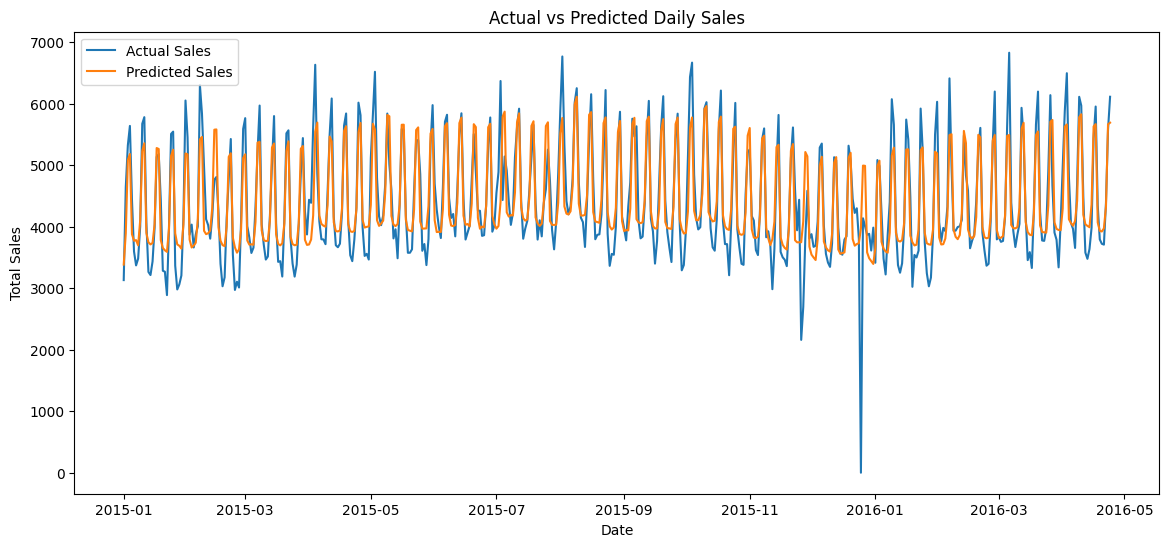

In [107]:
plt.figure(figsize=(14,6))

plt.plot(daily_results["date"], daily_results["actual"], label="Actual Sales")
plt.plot(daily_results["date"], daily_results["predicted"], label="Predicted Sales")

plt.title("Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()

plt.show()

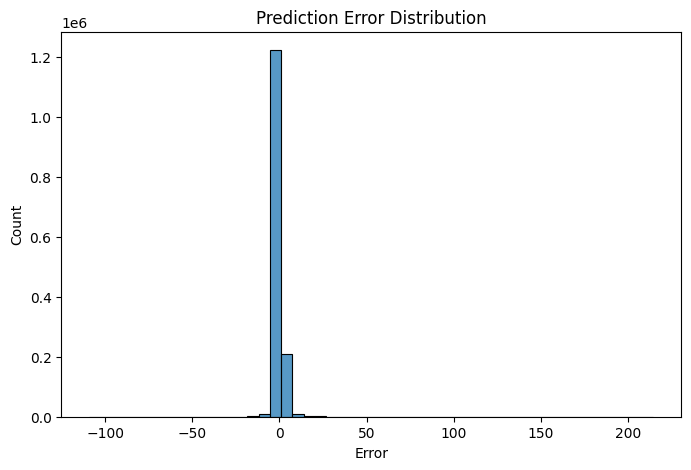

In [108]:
#grafico de errores
results["error"] = results["actual"] - results["predicted"]

plt.figure(figsize=(8,5))

sns.histplot(results["error"], bins=50)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.show()

In [109]:
improvement_rmse = (rmse_baseline - rmse_rf) / rmse_baseline
print("Improvement:", improvement_rmse * 100, "%")

Improvement: 25.45497268961175 %


Key insights
1. La demanda presenta alta intermitencia, con muchos días sin ventas.
2. Existe estacionalidad semanal, con mayores ventas en fines de semana.
3. La demanda depende principalmente de patrones históricos recientes.
4. El precio tiene un impacto moderado en la demanda.
5. El modelo reduce el error de predicción aproximadamente 25% frente al baseline.

In [110]:
joblib.dump(best_rf, "demand_forecasting_model.pkl")

['demand_forecasting_model.pkl']

In [111]:
df.to_csv("../processed/df_temporal_CA1.csv", index=False)

In [112]:
df.to_csv("../processed/df_model_CA1.csv", index=False)

In [113]:
item_stats = df.groupby("item_id")["sales"].agg(["mean","std"])
item_stats["cv"] = item_stats["std"] / item_stats["mean"]
item_stats = item_stats.reset_index()

In [114]:
item_stats.to_csv("../processed/item_volatility.csv", index=False)